In [ ]:

import torch
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU!')
print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), 'GB')

GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:

!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q pycocotools scikit-learn matplotlib
print('Дууслаа')

  Preparing metadata (setup.py) ... done
Дууслаа


In [ ]:

from google.colab import files
import os

if not os.path.exists('/content/FracAtlas'):
    print('kaggle.json upload хийнэ үү...')
    uploaded = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    !pip install -q kaggle
    print('FracAtlas татаж байна...')
    !kaggle datasets download -d mahmudulhasantasin/fracatlas-original-dataset -p /content --unzip -q
    print('Дууслаа')
else:
    print('FracAtlas аль хэдийн байна')

# Бүтэц шалгах
import os
for root, dirs, files_list in os.walk('/content/FracAtlas'):
    level = root.replace('/content/FracAtlas', '').count(os.sep)
    if level < 3:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if level < 2:
            subindent = ' ' * 2 * (level + 1)
            for f in files_list[:3]:
                print(f'{subindent}{f}')

kaggle.json upload хийнэ үү...


Saving kaggle.json to kaggle.json
FracAtlas татаж байна...
Dataset URL: https://www.kaggle.com/datasets/mahmudulhasantasin/fracatlas-original-dataset
License(s): CC0-1.0
Дууслаа
FracAtlas/
  dataset.csv
  Annotations/
    YOLO/
    COCO JSON/
    PASCAL VOC/
    VGG JSON/
  images/
    Non_fractured/
    Fractured/
  Utilities/
    yolo2voc.ipynb
    coco2yolo.ipynb
    Fracture Split/


In [ ]:
# Cell 4: SAM weight татах
import os
os.makedirs('/content/sam_seg/weights', exist_ok=True)
os.makedirs('/content/sam_seg/results', exist_ok=True)
os.makedirs('/content/sam_seg/checkpoints', exist_ok=True)

if not os.path.exists('/content/sam_seg/weights/sam_vit_b_01ec64.pth'):
    print('SAM weight татаж байна (~375MB)...')
    !wget -q --show-progress \
        https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth \
        -O /content/sam_seg/weights/sam_vit_b_01ec64.pth
    print('Дууслаа')
else:
    print('SAM weight байна')

SAM weight татаж байна (~375MB)...
/content/sam_seg/we 100%[===================>] 357.67M   222MB/s    in 1.6s    
Дууслаа


In [ ]:
# Cell 5: FracAtlas COCO annotation уншигч
import json
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from pycocotools import mask as coco_mask

# FracAtlas-ийн зам олох
import glob
coco_files = glob.glob('/content/**/*COCO*/*.json', recursive=True)
print('COCO файлууд:', coco_files)

fractured_dirs = glob.glob('/content/**/Fractured', recursive=True)
print('Fractured хавтас:', fractured_dirs)

COCO файлууд: ['/content/FracAtlas/Annotations/COCO JSON/COCO_fracture_masks.json']
Fractured хавтас: ['/content/FracAtlas/images/Fractured']


In [ ]:
# Cell 6: Датасет бүтэц тохируулах
import json, os
import numpy as np
from pathlib import Path
from PIL import Image
from pycocotools import mask as mask_util

# Замуудыг тохируулна — FracAtlas-ийн бодит байршилд тааруулна
BASE = Path('/content/FracAtlas')

# COCO JSON файл хайх
coco_json = None
for p in BASE.rglob('*.json'):
    if 'COCO' in str(p) or 'coco' in str(p).lower():
        coco_json = p
        break

if coco_json is None:
    # Бүх JSON файл харуулах
    jsons = list(BASE.rglob('*.json'))
    print('JSON файлууд:')
    for j in jsons: print(' ', j)
    coco_json = jsons[0] if jsons else None

print('COCO JSON:', coco_json)

# Fractured зургийн хавтас
fractured_dir = None
for p in BASE.rglob('Fractured'):
    if p.is_dir():
        fractured_dir = p
        break

print('Fractured хавтас:', fractured_dir)
if fractured_dir:
    imgs = list(fractured_dir.glob('*.jpg')) + list(fractured_dir.glob('*.png'))
    print(f'Fractured зураг: {len(imgs)}')

COCO JSON: /content/FracAtlas/Annotations/COCO JSON/COCO_fracture_masks.json
Fractured хавтас: /content/FracAtlas/images/Fractured
Fractured зураг: 717


Нийт sample: 717


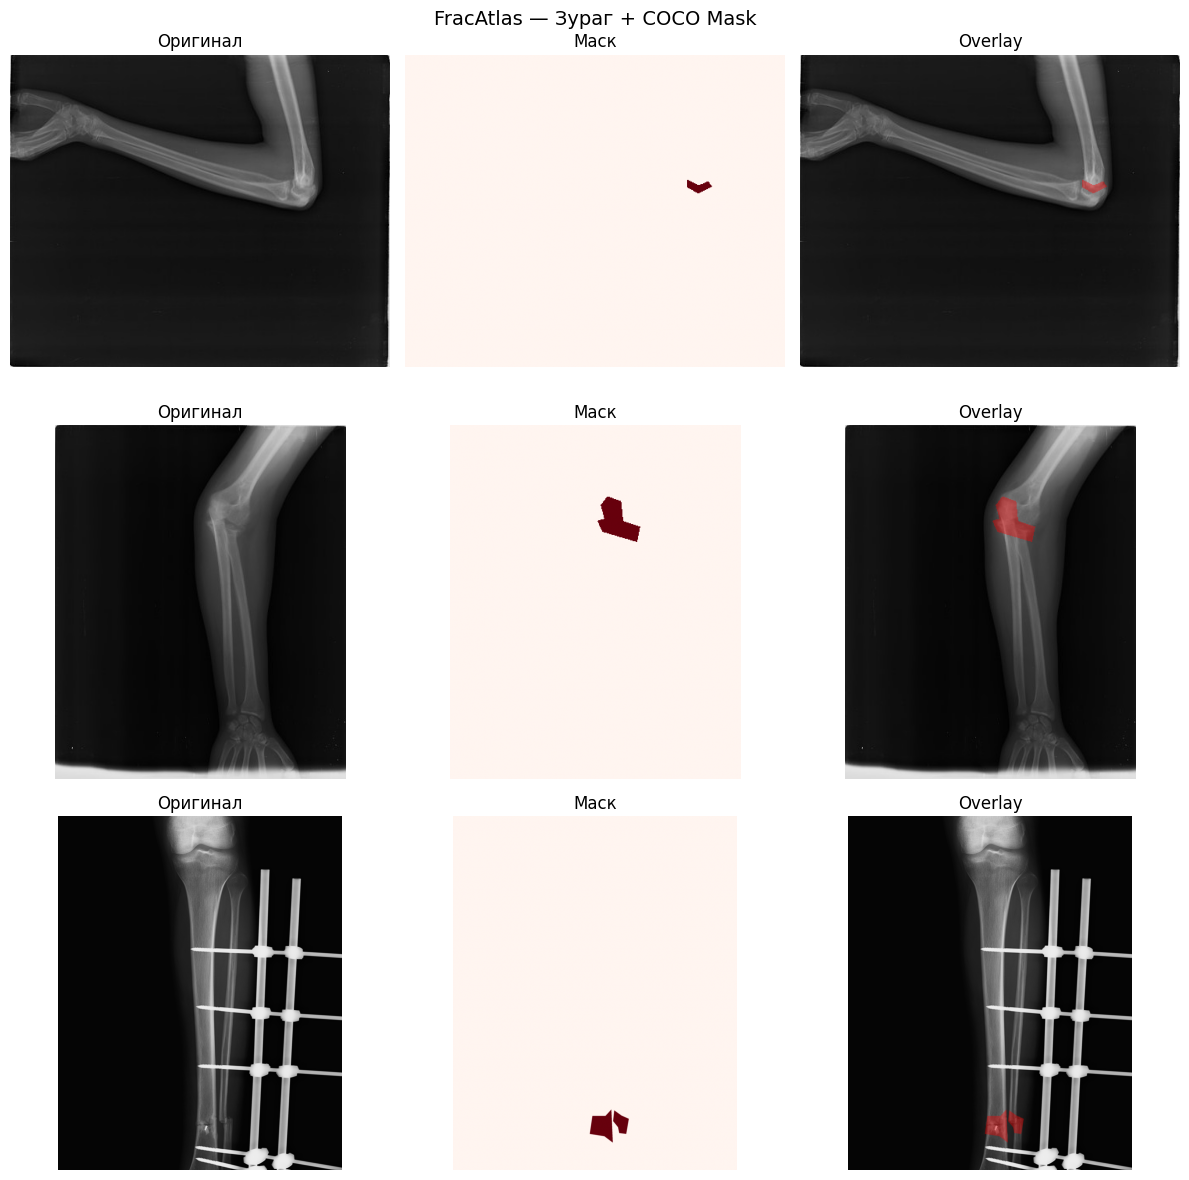

Датасет бэлэн!


In [ ]:
# Cell 7: COCO mask уншиж зургаар харуулах
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools import mask as mask_util
import random

def load_fracatlas_samples(coco_json_path, img_dir):
    """COCO JSON-аас (зураг, маск) жагсаалт үүсгэнэ"""
    with open(coco_json_path) as f:
        coco = json.load(f)

    # image_id -> file_name
    id_to_file = {img['id']: img['file_name'] for img in coco['images']}

    # image_id -> annotations
    from collections import defaultdict
    id_to_anns = defaultdict(list)
    for ann in coco['annotations']:
        id_to_anns[ann['image_id']].append(ann)

    samples = []
    img_dir = Path(img_dir)

    for img_id, file_name in id_to_file.items():
        # Зургийн зам олох
        img_path = img_dir / file_name
        if not img_path.exists():
            # Хавтас дотор хайх
            found = list(img_dir.rglob(file_name))
            if not found:
                continue
            img_path = found[0]

        anns = id_to_anns[img_id]
        if not anns:
            continue

        samples.append({
            'img_path': str(img_path),
            'img_id':   img_id,
            'anns':     anns,
        })

    print(f'Нийт sample: {len(samples)}')
    return samples, coco

def ann_to_mask(ann, height, width):
    """COCO annotation-г binary mask болгоно"""
    seg = ann['segmentation']
    if isinstance(seg, list):
        # Polygon
        rle = mask_util.frPyObjects(seg, height, width)
        m   = mask_util.decode(mask_util.merge(rle))
    else:
        # RLE
        m = mask_util.decode(seg)
    return m.astype(np.uint8)

def get_combined_mask(anns, height, width):
    """Олон annotation-г нэг маск болгоно"""
    combined = np.zeros((height, width), dtype=np.uint8)
    for ann in anns:
        m = ann_to_mask(ann, height, width)
        combined = np.maximum(combined, m)
    return combined

# Sample уншиж харуулах
samples, coco_data = load_fracatlas_samples(coco_json, fractured_dir)

# 3 жишээ харуулах
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('FracAtlas — Зураг + COCO Mask', fontsize=14)

chosen = random.sample(samples, min(3, len(samples)))
for i, sample in enumerate(chosen):
    img    = np.array(Image.open(sample['img_path']).convert('RGB'))
    h, w   = img.shape[:2]
    mask   = get_combined_mask(sample['anns'], h, w)
    overlay = img.copy()
    overlay[mask==1] = [255, 0, 0]  # улаан
    blended = (img * 0.6 + overlay * 0.4).astype(np.uint8)

    axes[i,0].imshow(img, cmap='gray')
    axes[i,0].set_title('Оригинал'); axes[i,0].axis('off')

    axes[i,1].imshow(mask, cmap='Reds')
    axes[i,1].set_title('Маск'); axes[i,1].axis('off')

    axes[i,2].imshow(blended)
    axes[i,2].set_title('Overlay'); axes[i,2].axis('off')

plt.tight_layout()
plt.savefig('/content/sam_seg/results/fracatlas_samples.png', dpi=120)
plt.show()
print('Датасет бэлэн!')

In [ ]:
# Cell 8: SAM Zero-shot сегментлэл
# Сургалтгүйгээр SAM-г bbox prompt-оор ажиллуулна

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from segment_anything import sam_model_registry, SamPredictor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# SAM ачаалах
sam = sam_model_registry['vit_b'](checkpoint='/content/sam_seg/weights/sam_vit_b_01ec64.pth')
sam = sam.to(device)
predictor = SamPredictor(sam)
print('SAM бэлэн')

def get_bbox_from_mask(mask):
    """Ground truth mask-аас bbox гаргана (zero-shot prompt болгоно)"""
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return np.array([cmin, rmin, cmax, rmax])  # [x1,y1,x2,y2]

def dice_score(pred, gt):
    """Dice coefficient тооцоолно"""
    intersection = (pred * gt).sum()
    return 2 * intersection / (pred.sum() + gt.sum() + 1e-6)

def iou_score(pred, gt):
    """IoU тооцоолно"""
    intersection = (pred & gt).sum()
    union        = (pred | gt).sum()
    return intersection / (union + 1e-6)

# Zero-shot үнэлгээ
print('\nZero-shot сегментлэл хийж байна...')
dice_scores = []
iou_scores  = []
test_samples = random.sample(samples, min(50, len(samples)))

for sample in test_samples:
    img  = np.array(Image.open(sample['img_path']).convert('RGB'))
    h, w = img.shape[:2]
    gt_mask = get_combined_mask(sample['anns'], h, w)

    if gt_mask.sum() == 0:
        continue

    # SAM-д зураг өгөх
    predictor.set_image(img)

    # Bbox prompt (GT маскаас авна)
    bbox = get_bbox_from_mask(gt_mask)
    masks, scores, _ = predictor.predict(
        box=bbox[None, :],
        multimask_output=False
    )
    pred_mask = masks[0].astype(np.uint8)

    dice = dice_score(pred_mask, gt_mask)
    iou  = iou_score(pred_mask.astype(bool), gt_mask.astype(bool))
    dice_scores.append(dice)
    iou_scores.append(iou)

print(f'\nZero-shot үр дүн ({len(dice_scores)} зураг):')
print(f'  Dice Score: {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}')
print(f'  IoU Score:  {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}')

Device: cuda
SAM бэлэн

Zero-shot сегментлэл хийж байна...

Zero-shot үр дүн (50 зураг):
  Dice Score: 0.6854 ± 0.1674
  IoU Score:  0.5423 ± 0.1674


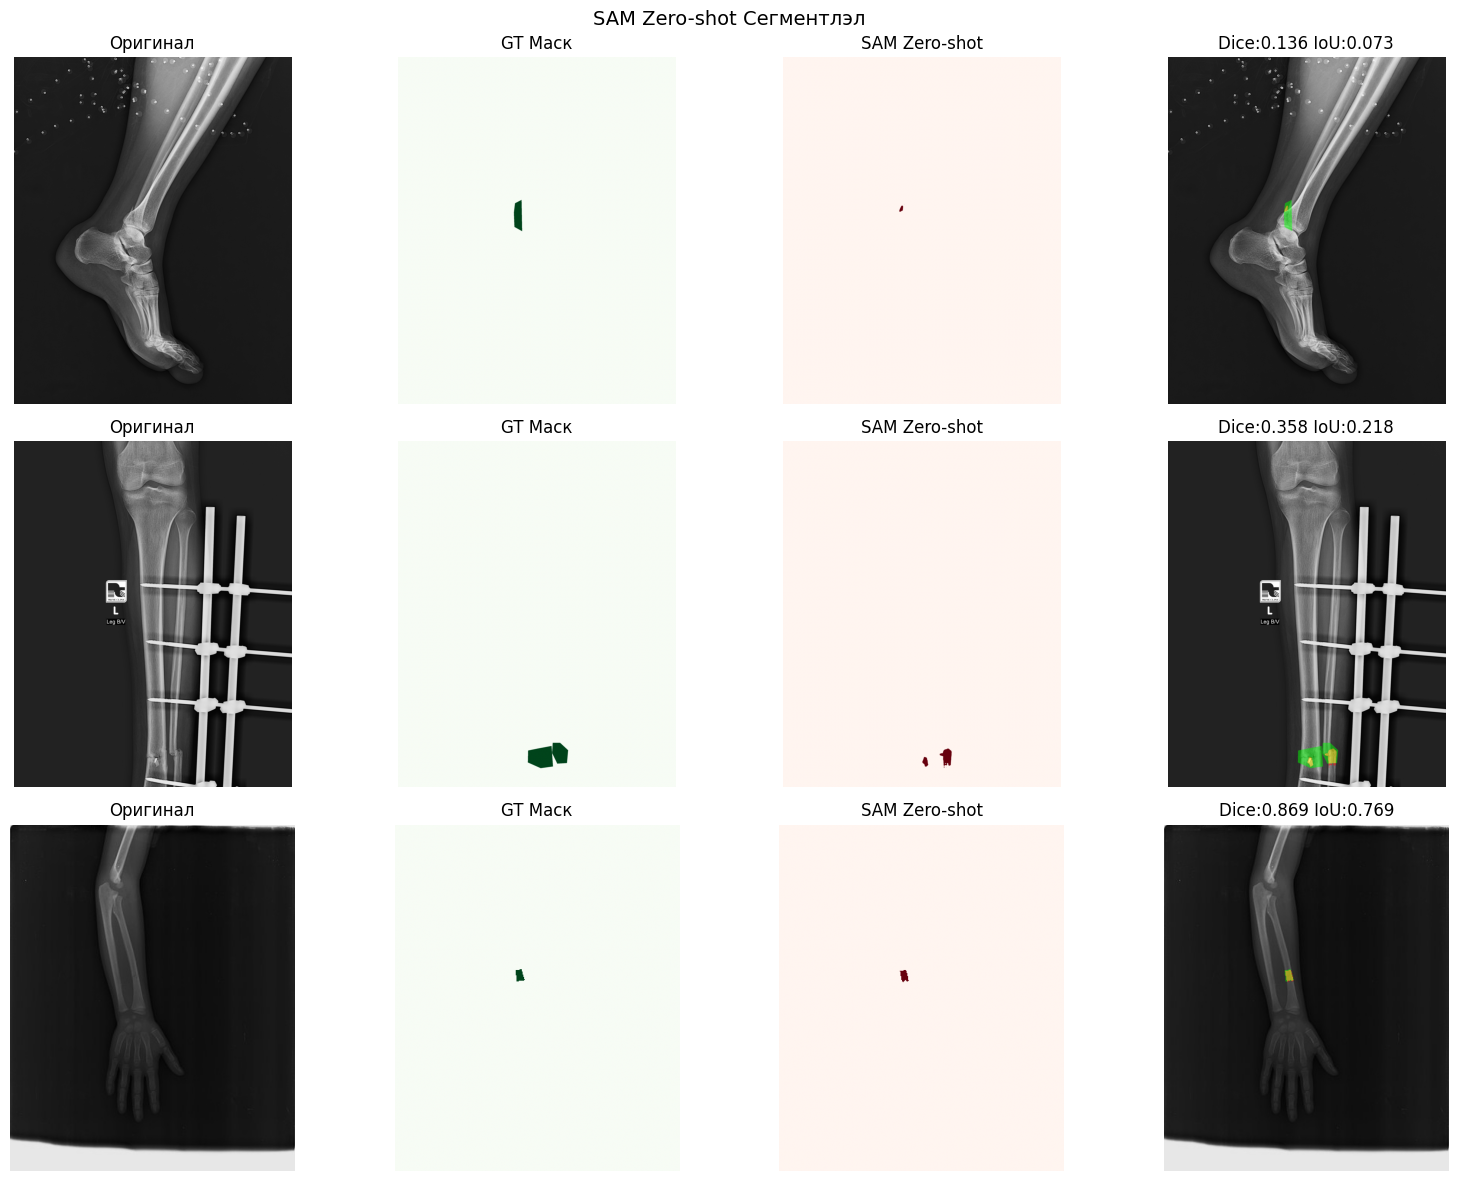

In [ ]:
# Cell 9: Zero-shot үр дүн зургаар харуулах
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('SAM Zero-shot Сегментлэл', fontsize=14)

vis_samples = random.sample(samples, min(3, len(samples)))
for i, sample in enumerate(vis_samples):
    img     = np.array(Image.open(sample['img_path']).convert('RGB'))
    h, w    = img.shape[:2]
    gt_mask = get_combined_mask(sample['anns'], h, w)

    predictor.set_image(img)
    bbox = get_bbox_from_mask(gt_mask)
    masks, _, _ = predictor.predict(
        box=bbox[None, :],
        multimask_output=False
    )
    pred_mask = masks[0].astype(np.uint8)

    dice = dice_score(pred_mask, gt_mask)
    iou  = iou_score(pred_mask.astype(bool), gt_mask.astype(bool))

    axes[i,0].imshow(img, cmap='gray'); axes[i,0].set_title('Оригинал'); axes[i,0].axis('off')
    axes[i,1].imshow(gt_mask, cmap='Greens'); axes[i,1].set_title('GT Маск'); axes[i,1].axis('off')
    axes[i,2].imshow(pred_mask, cmap='Reds'); axes[i,2].set_title(f'SAM Zero-shot'); axes[i,2].axis('off')

    # Overlay
    overlay = img.copy()
    overlay[gt_mask==1]   = [0,255,0]  # ногоон = GT
    overlay[pred_mask==1] = [255,0,0]  # улаан = SAM
    both = (gt_mask==1) & (pred_mask==1)
    overlay[both] = [255,255,0]  # шар = давхцал
    blended = (img*0.5 + overlay*0.5).astype(np.uint8)
    axes[i,3].imshow(blended)
    axes[i,3].set_title(f'Dice:{dice:.3f} IoU:{iou:.3f}')
    axes[i,3].axis('off')

plt.tight_layout()
plt.savefig('/content/sam_seg/results/zeroshot_results.png', dpi=120)
plt.show()

In [ ]:
# Cell 10: SAM Fine-tune — Dataset
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import random

# Train/val хуваалт
random.seed(42)
random.shuffle(samples)
n_train = int(len(samples) * 0.8)
train_samples = samples[:n_train]
val_samples   = samples[n_train:]
print(f'Train: {len(train_samples)} | Val: {len(val_samples)}')

class FracAtlasSegDataset(Dataset):
    def __init__(self, samples, img_size=256):
        self.samples  = samples
        self.img_size = img_size
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample  = self.samples[idx]
        img_pil = Image.open(sample['img_path']).convert('RGB')
        w_orig, h_orig = img_pil.size

        # GT маск
        gt_mask = get_combined_mask(sample['anns'], h_orig, w_orig)
        gt_pil  = Image.fromarray(gt_mask * 255).resize(
            (self.img_size, self.img_size), Image.NEAREST
        )
        gt_tensor = torch.tensor(np.array(gt_pil) > 127, dtype=torch.float32).unsqueeze(0)

        # Bbox (SAM prompt)
        if gt_mask.sum() > 0:
            bbox = get_bbox_from_mask(gt_mask).astype(np.float32)
            bbox[0] = bbox[0] * self.img_size / w_orig
            bbox[1] = bbox[1] * self.img_size / h_orig
            bbox[2] = bbox[2] * self.img_size / w_orig
            bbox[3] = bbox[3] * self.img_size / h_orig
        else:
            bbox = np.array([0, 0, self.img_size, self.img_size], dtype=np.float32)

        return self.transform(img_pil), gt_tensor, torch.tensor(bbox)

train_ds = FracAtlasSegDataset(train_samples, img_size=256)
val_ds   = FracAtlasSegDataset(val_samples,   img_size=256)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2)
print('DataLoader бэлэн')

Train: 573 | Val: 144
DataLoader бэлэн


In [ ]:
# Cell 11: SAM Fine-tune — Загвар
import torch
import torch.nn as nn
import torch.nn.functional as F
from segment_anything import sam_model_registry

class SAMFineTuner(nn.Module):
    """
    SAM Fine-tune загвар:
    - Image encoder хөлдөөнө (хурдан сургахын тулд)
    - Mask decoder сургана (хугарлын маск гаргахад тохируулна)
    """
    def __init__(self, checkpoint, model_type='vit_b', img_size=256):
        super().__init__()
        sam = sam_model_registry[model_type](checkpoint=checkpoint)

        # Encoder хөлдөөх
        self.image_encoder   = sam.image_encoder
        for p in self.image_encoder.parameters():
            p.requires_grad = False

        # Prompt encoder + mask decoder сургана
        self.prompt_encoder  = sam.prompt_encoder
        self.mask_decoder    = sam.mask_decoder
        self.img_size        = img_size
        self.sam_img_size    = sam.image_encoder.img_size  # 1024

    def forward(self, images, bboxes):
        B = images.shape[0]

        # Image encoding
        with torch.no_grad():
            # SAM 1024x1024 шаардана — resize хийнэ
            imgs_1024 = F.interpolate(images, size=(1024,1024),
                                      mode='bilinear', align_corners=False)
            img_emb   = self.image_encoder(imgs_1024)  # (B, 256, 64, 64)

        # Bbox prompt
        # bboxes: (B, 4) → SAM-д (B, 1, 4) формат
        scale    = 1024 / self.img_size
        bboxes_scaled = bboxes * scale  # 256 → 1024 scale

        pred_masks = []
        for i in range(B):
            box = bboxes_scaled[i:i+1]  # (1, 4)
            sparse_emb, dense_emb = self.prompt_encoder(
                points=None,
                boxes=box,
                masks=None
            )
            low_res_masks, _ = self.mask_decoder(
                image_embeddings=img_emb[i:i+1],
                image_pe=self.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sparse_emb,
                dense_prompt_embeddings=dense_emb,
                multimask_output=False
            )
            # (1, 1, 256, 256) → (1, 1, img_size, img_size)
            mask = F.interpolate(low_res_masks, size=(self.img_size, self.img_size),
                                 mode='bilinear', align_corners=False)
            pred_masks.append(mask)

        return torch.cat(pred_masks, dim=0)  # (B, 1, H, W)


class DiceBCELoss(nn.Module):
    """Segmentation-д хамгийн сайн ажилладаг loss"""
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, gt):
        bce_loss  = self.bce(pred, gt)
        pred_sig  = torch.sigmoid(pred)
        inter     = (pred_sig * gt).sum(dim=(2,3))
        dice_loss = 1 - (2*inter + 1) / (pred_sig.sum(dim=(2,3)) + gt.sum(dim=(2,3)) + 1)
        return bce_loss + dice_loss.mean()


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = SAMFineTuner('/content/sam_seg/weights/sam_vit_b_01ec64.pth').to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Нийт параметр:   {total:,}')
print(f'Сургах параметр: {trainable:,}')
print('Загвар бэлэн')

Нийт параметр:   93,735,472
Сургах параметр: 4,064,560
Загвар бэлэн


In [ ]:
# Шинэ cell нэмж ажиллуулна уу
import torch
torch.cuda.empty_cache()

# Batch size багасгах + img_size багасгах
train_ds = FracAtlasSegDataset(train_samples, img_size=128)  # 256 → 128
val_ds   = FracAtlasSegDataset(val_samples,   img_size=128)

train_loader = DataLoader(train_ds, batch_size=2,  # 8 → 2
                          shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=2,
                          shuffle=False, num_workers=2)

print('DataLoader шинэчлэгдлээ')
print('img_size: 128 | batch_size: 2')

DataLoader шинэчлэгдлээ
img_size: 128 | batch_size: 2


In [ ]:
# Loss функцыг засах — pred-г mask-ийн хэмжээнд resize хийнэ
import torch.nn.functional as F

class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, gt):
        # Pred-г gt-ийн хэмжээнд тохируулах
        if pred.shape != gt.shape:
            pred = F.interpolate(pred, size=gt.shape[2:],
                                 mode='bilinear', align_corners=False)
        bce_loss = self.bce(pred, gt)
        pred_sig = torch.sigmoid(pred)
        inter    = (pred_sig * gt).sum(dim=(2,3))
        dice_loss = 1 - (2*inter + 1) / (pred_sig.sum(dim=(2,3)) + gt.sum(dim=(2,3)) + 1)
        return bce_loss + dice_loss.mean()

loss_fn = DiceBCELoss()
print('Loss функц засагдлаа')

Loss функц засагдлаа


In [ ]:
# dice_score, iou_score функцуудыг засах
import torch.nn.functional as F

def dice_score(pred, gt):
    """Dice coefficient — хэмжээ тохируулж тооцоолно"""
    if pred.shape != gt.shape:
        pred = np.array(Image.fromarray(pred.astype(np.uint8)*255).resize(
            (gt.shape[1], gt.shape[0]), Image.NEAREST)) > 127
        pred = pred.astype(np.float32)
    intersection = (pred * gt).sum()
    return 2 * intersection / (pred.sum() + gt.sum() + 1e-6)

def iou_score(pred, gt):
    """IoU — хэмжээ тохируулж тооцоолно"""
    if pred.shape != gt.shape:
        pred = np.array(Image.fromarray(pred.astype(np.uint8)*255).resize(
            (gt.shape[1], gt.shape[0]), Image.NEAREST)) > 127
    intersection = (pred & gt).sum()
    union        = (pred | gt).sum()
    return intersection / (union + 1e-6)

print('Функцууд засагдлаа — Cell 12 дахин ажиллуулна уу')

Функцууд засагдлаа — Cell 12 дахин ажиллуулна уу


In [ ]:
# Cell 12: SAM Fine-tune — Сургалт
import torch.optim as optim
import time, json
import numpy as np

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
loss_fn  = DiceBCELoss()
EPOCHS   = 20
best_dice = 0.0
history   = []

print(f'SAM Fine-tune сургалт — {EPOCHS} epoch')
print('='*60)

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss = 0.0
    start = time.time()

    for i, (imgs, masks, bboxes) in enumerate(train_loader):
        imgs   = imgs.to(device)
        masks  = masks.to(device)
        bboxes = bboxes.to(device)

        preds = model(imgs, bboxes)
        loss  = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

        if i % 10 == 0:
            print(f'  Epoch {epoch+1} | Step {i}/{len(train_loader)} | Loss: {loss.item():.4f}')

    # Validation
    model.eval()
    val_dices = []
    val_ious  = []

    with torch.no_grad():
        for imgs, masks, bboxes in val_loader:
            imgs   = imgs.to(device)
            masks  = masks.to(device)
            bboxes = bboxes.to(device)

            preds     = torch.sigmoid(model(imgs, bboxes))
            pred_bin  = (preds > 0.5).float()

            for p, g in zip(pred_bin.cpu().numpy(), masks.cpu().numpy()):
                val_dices.append(dice_score(p[0], g[0]))
                val_ious.append(iou_score(p[0].astype(bool), g[0].astype(bool)))

    mean_dice = float(np.mean(val_dices))   # ← float32 → float
    mean_iou  = float(np.mean(val_ious))    # ← float32 → float
    elapsed   = time.time() - start

    print(f'\nEpoch {epoch+1:3d}/{EPOCHS} ({elapsed:.0f}s)')
    print(f'  Train Loss: {train_loss/len(train_loader):.4f}')
    print(f'  Val Dice:   {mean_dice:.4f} | Val IoU: {mean_iou:.4f}')
    print('-'*60)

    history.append({
        'epoch':      epoch + 1,
        'train_loss': round(train_loss / len(train_loader), 6),
        'val_dice':   round(mean_dice, 6),
        'val_iou':    round(mean_iou, 6)
    })

    if mean_dice > best_dice:
        best_dice = mean_dice
        torch.save({
            'epoch':       epoch + 1,
            'model_state': model.state_dict(),
            'val_dice':    best_dice
        }, '/content/sam_seg/checkpoints/sam_finetune_best.pth')
        print(f'  Checkpoint хадгалагдлаа. Best Dice: {best_dice:.4f}')

with open('/content/sam_seg/results/finetune_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f'\nСургалт дууслаа! Best Val Dice: {best_dice:.4f}')

SAM Fine-tune сургалт — 20 epoch
  Epoch 1 | Step 0/287 | Loss: 1.0506
  Epoch 1 | Step 10/287 | Loss: 1.0329
  Epoch 1 | Step 20/287 | Loss: 1.0385
  Epoch 1 | Step 30/287 | Loss: 0.9857
  Epoch 1 | Step 40/287 | Loss: 1.0642
  Epoch 1 | Step 50/287 | Loss: 0.9720
  Epoch 1 | Step 60/287 | Loss: 0.8188
  Epoch 1 | Step 70/287 | Loss: 0.7001
  Epoch 1 | Step 80/287 | Loss: 0.7561
  Epoch 1 | Step 90/287 | Loss: 0.5636
  Epoch 1 | Step 100/287 | Loss: 0.8748
  Epoch 1 | Step 110/287 | Loss: 0.8169
  Epoch 1 | Step 120/287 | Loss: 0.7727
  Epoch 1 | Step 130/287 | Loss: 0.7594
  Epoch 1 | Step 140/287 | Loss: 0.4603
  Epoch 1 | Step 150/287 | Loss: 0.8434
  Epoch 1 | Step 160/287 | Loss: 0.4207
  Epoch 1 | Step 170/287 | Loss: 1.0666
  Epoch 1 | Step 180/287 | Loss: 0.6073
  Epoch 1 | Step 190/287 | Loss: 0.7767
  Epoch 1 | Step 200/287 | Loss: 0.6112
  Epoch 1 | Step 210/287 | Loss: 0.6806
  Epoch 1 | Step 220/287 | Loss: 0.5846
  Epoch 1 | Step 230/287 | Loss: 0.3967
  Epoch 1 | Step 2

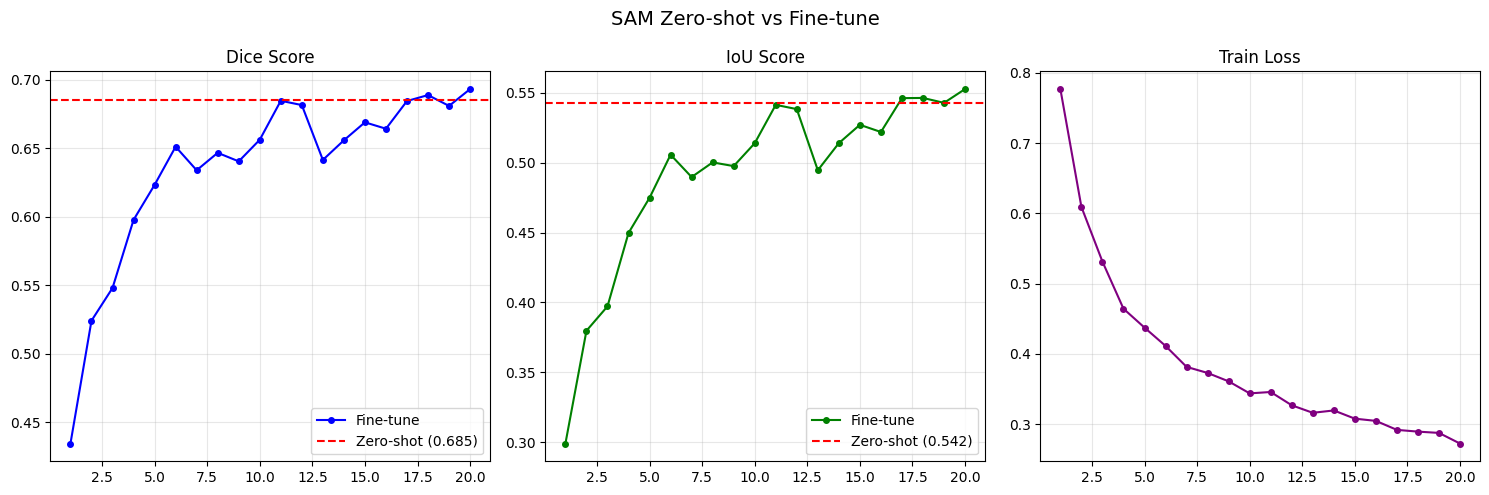


===== Эцсийн харьцуулалт =====
Zero-shot  — Dice: 0.6854 | IoU: 0.5423
Fine-tune  — Dice: 0.6930 | IoU: 0.5527
Сайжралт:  +1.1% (Dice)


In [ ]:
# Cell 13: Zero-shot vs Fine-tune харьцуулалт
import matplotlib.pyplot as plt
import json

with open('/content/sam_seg/results/finetune_history.json') as f:
    history = json.load(f)

epochs    = [h['epoch']     for h in history]
val_dice  = [h['val_dice']  for h in history]
val_iou   = [h['val_iou']   for h in history]
train_loss= [h['train_loss'] for h in history]

zeroshot_dice = np.mean(dice_scores)
zeroshot_iou  = np.mean(iou_scores)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('SAM Zero-shot vs Fine-tune', fontsize=14)

axes[0].plot(epochs, val_dice, 'b-o', label='Fine-tune', markersize=4)
axes[0].axhline(y=zeroshot_dice, color='r', linestyle='--', label=f'Zero-shot ({zeroshot_dice:.3f})')
axes[0].set_title('Dice Score'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, val_iou, 'g-o', label='Fine-tune', markersize=4)
axes[1].axhline(y=zeroshot_iou, color='r', linestyle='--', label=f'Zero-shot ({zeroshot_iou:.3f})')
axes[1].set_title('IoU Score'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, train_loss, 'purple', marker='o', markersize=4)
axes[2].set_title('Train Loss'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/sam_seg/results/comparison.png', dpi=150)
plt.show()

print('\n===== Эцсийн харьцуулалт =====')
print(f'Zero-shot  — Dice: {zeroshot_dice:.4f} | IoU: {zeroshot_iou:.4f}')
print(f'Fine-tune  — Dice: {max(val_dice):.4f} | IoU: {max(val_iou):.4f}')
improvement_dice = (max(val_dice) - zeroshot_dice) / zeroshot_dice * 100
print(f'Сайжралт:  {improvement_dice:+.1f}% (Dice)')

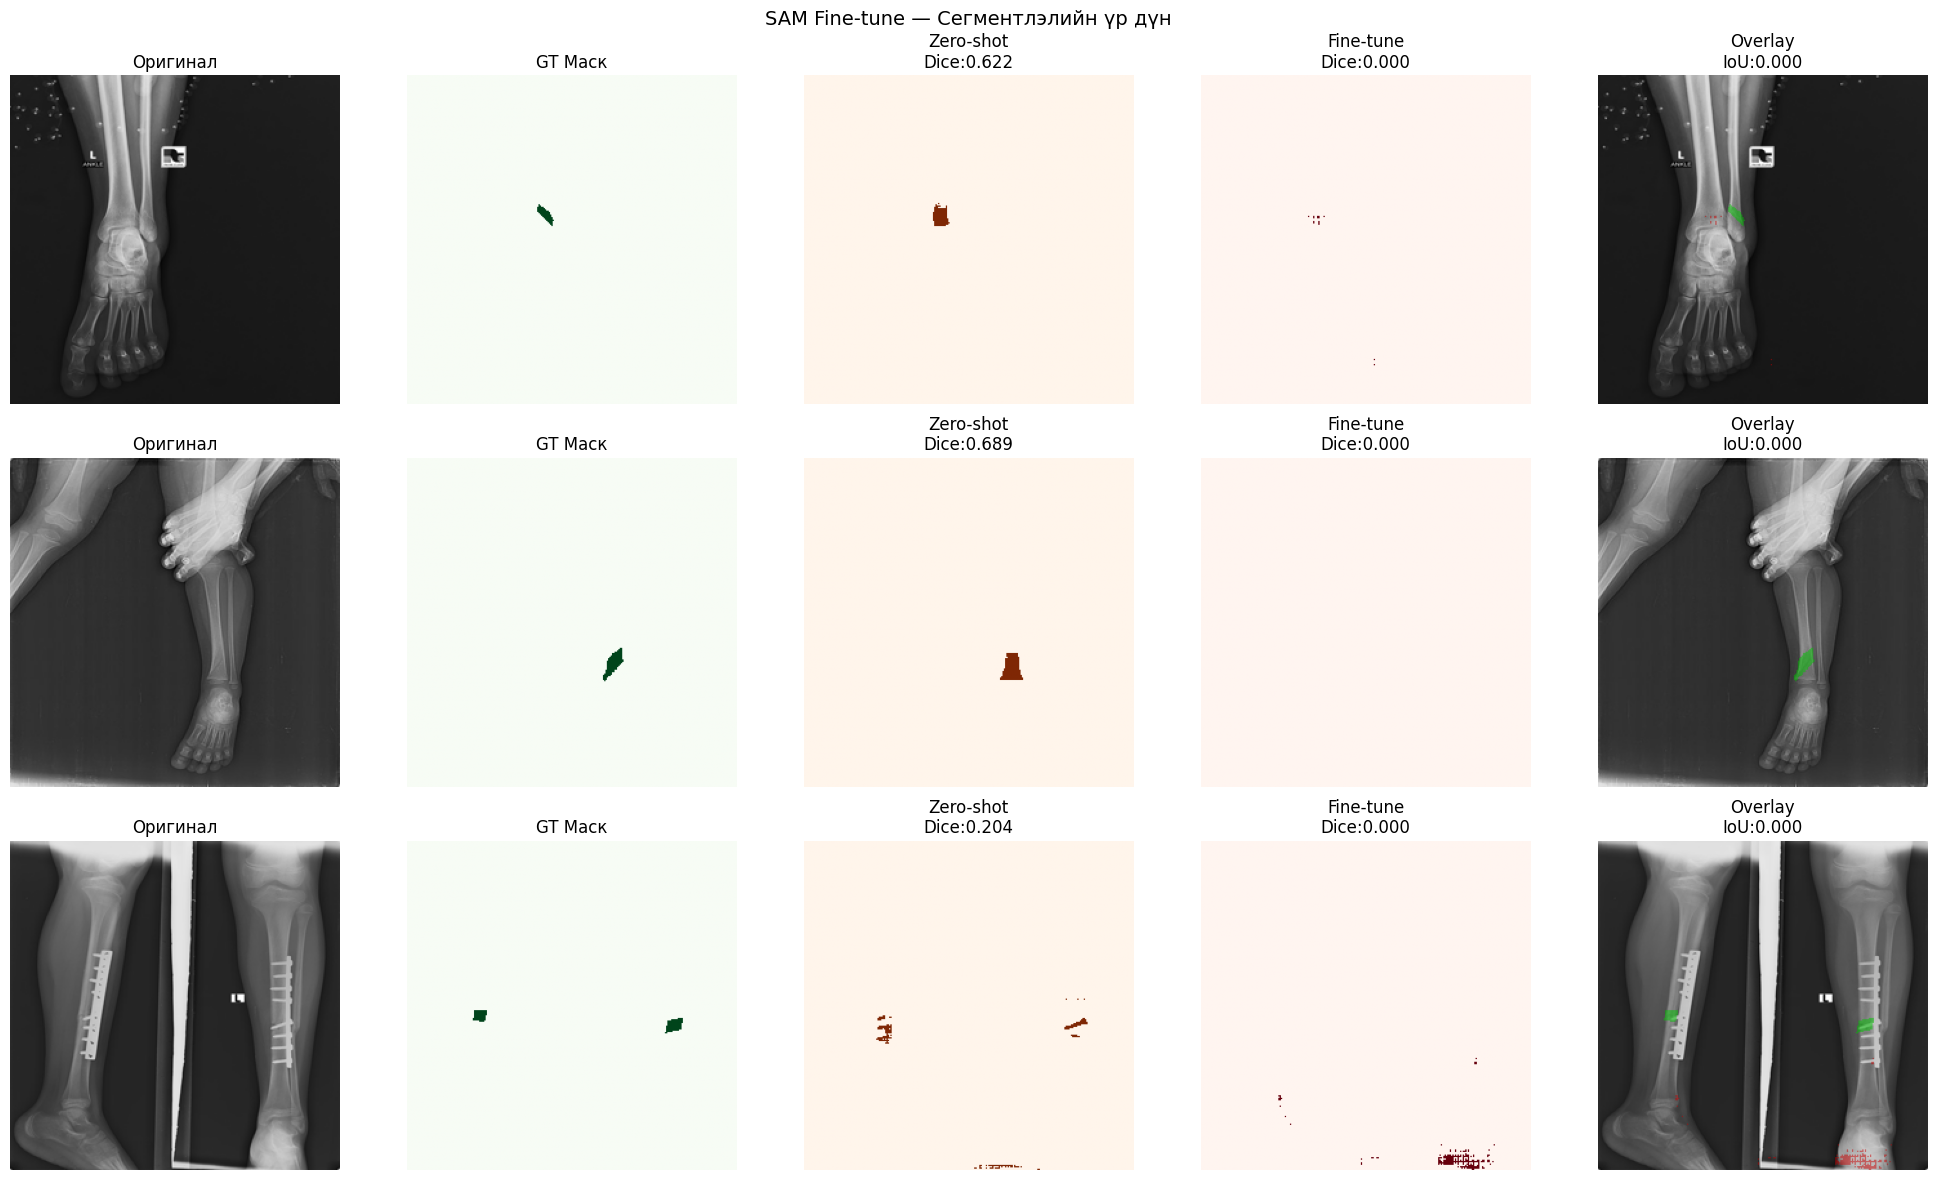

In [ ]:
# Cell 14: Fine-tune үр дүн зургаар харуулах
model.eval()
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('SAM Fine-tune — Сегментлэлийн үр дүн', fontsize=14)

vis_samples = random.sample(val_samples, min(3, len(val_samples)))
for i, sample in enumerate(vis_samples):
    img_pil = Image.open(sample['img_path']).convert('RGB')
    w, h    = img_pil.size
    gt_mask = get_combined_mask(sample['anns'], h, w)

    # Fine-tune загварын таамаглал
    img_t = FracAtlasSegDataset([sample])[0][0].unsqueeze(0).to(device)
    bbox_arr = get_bbox_from_mask(gt_mask).astype(np.float32)
    scale = 256 / max(h, w)
    bbox_t = torch.tensor(bbox_arr * scale).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(img_t, bbox_t))
        pred_mask = (pred > 0.5).squeeze().cpu().numpy().astype(np.uint8)

    img_np = np.array(img_pil.resize((256,256)))
    gt_resized = np.array(Image.fromarray(gt_mask*255).resize((256,256), Image.NEAREST)) > 127

    dice_ft = dice_score(pred_mask, gt_resized.astype(np.uint8))
    iou_ft  = iou_score(pred_mask.astype(bool), gt_resized)

    # Zero-shot
    predictor.set_image(np.array(img_pil))
    bbox_orig = get_bbox_from_mask(gt_mask)
    zs_masks, _, _ = predictor.predict(box=bbox_orig[None,:], multimask_output=False)
    zs_mask = zs_masks[0].astype(np.uint8)
    zs_resized = np.array(Image.fromarray(zs_mask*255).resize((256,256), Image.NEAREST)) > 127
    dice_zs = dice_score(zs_resized.astype(np.uint8), gt_resized.astype(np.uint8))

    axes[i,0].imshow(img_np, cmap='gray'); axes[i,0].set_title('Оригинал'); axes[i,0].axis('off')
    axes[i,1].imshow(gt_resized, cmap='Greens'); axes[i,1].set_title('GT Маск'); axes[i,1].axis('off')
    axes[i,2].imshow(zs_resized, cmap='Oranges'); axes[i,2].set_title(f'Zero-shot\nDice:{dice_zs:.3f}'); axes[i,2].axis('off')
    axes[i,3].imshow(pred_mask, cmap='Reds'); axes[i,3].set_title(f'Fine-tune\nDice:{dice_ft:.3f}'); axes[i,3].axis('off')

    overlay = np.stack([img_np[:,:,0]]*3, axis=-1)
    vis = img_np.copy()
    vis[gt_resized]  = [0,200,0]
    vis[pred_mask==1] = [200,0,0]
    vis[gt_resized & (pred_mask==1)] = [200,200,0]
    axes[i,4].imshow((img_np*0.5 + vis*0.5).astype(np.uint8))
    axes[i,4].set_title(f'Overlay\nIoU:{iou_ft:.3f}'); axes[i,4].axis('off')

plt.tight_layout()
plt.savefig('/content/sam_seg/results/finetune_visualization.png', dpi=120)
plt.show()

In [ ]:
# Cell 15: Checkpoint Drive-д хадгалах
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import shutil, os

save_dir = '/content/drive/MyDrive/fracture_results/sam_segmentation'
os.makedirs(save_dir, exist_ok=True)

shutil.copy('/content/sam_seg/checkpoints/sam_finetune_best.pth', save_dir)
shutil.copy('/content/sam_seg/results/finetune_history.json',     save_dir)
shutil.copy('/content/sam_seg/results/comparison.png',            save_dir)
shutil.copy('/content/sam_seg/results/finetune_visualization.png', save_dir)

print('Drive-д хадгалагдлаа:', save_dir)

Mounted at /content/drive
Drive-д хадгалагдлаа: /content/drive/MyDrive/fracture_results/sam_segmentation
